# Santander Value Prediction

Самостоятельный ML-проект по регрессии на разреженных табличных данных: исследовательский анализ, создание агрегированных признаков, единое сравнение моделей, подбор гиперпараметров и финальный ансамбль.

**Цель:** предсказать непрерывную целевую величину по 4 991 анонимизированному признаку.  
**Основная метрика:** RMSLE; обучение ведётся для `log1p(target)`, поэтому она эквивалентна RMSE в логарифмическом пространстве.

Данные: [Kaggle — Santander Value Prediction Challenge](https://www.kaggle.com/competitions/santander-value-prediction-challenge/data).


## 1. Импорты и настройки

In [1]:
from pathlib import Path
import json
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    ExtraTreesRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS = 5
N_TUNING_SPLITS = 3
N_SEARCH_ITER = 5
N_TOP_RAW_FEATURES = 600
N_JOBS = 4
RUN_LIGHTGBM = True

pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid", context="notebook")


## 2. Загрузка данных

In [2]:
data_candidates = [
    Path("data/santander-value-prediction-challenge"),
    Path("data"),
]
if os.getenv("SANTANDER_DATA_PATH"):
    data_candidates.insert(0, Path(os.environ["SANTANDER_DATA_PATH"]))

DATA_PATH = next(
    (path for path in data_candidates if (path / "train.csv").exists()),
    None,
)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Не найдены train.csv, test.csv и sample_submission.csv. "
        "Скачайте данные Kaggle в data/santander-value-prediction-challenge "
        "или задайте переменную SANTANDER_DATA_PATH."
    )

train = pd.read_csv(DATA_PATH / "train.csv")
test = pd.read_csv(DATA_PATH / "test.csv")
sample_sub = pd.read_csv(DATA_PATH / "sample_submission.csv")

TARGET = "target"
ID_COL = "ID"
RAW_FEATURES = [c for c in train.columns if c not in [ID_COL, TARGET]]

print("Каталог данных найден; файлы загружены.")
print(f"Train: {train.shape[0]} строк × {train.shape[1]} столбцов")
print(f"Test:  {test.shape[0]} строк × {test.shape[1]} столбцов")
display(train.head())


Каталог данных найден; файлы загружены.
Train: 4459 строк × 4993 столбцов
Test:  49342 строк × 4992 столбцов


,ID,target,48df886f9,0deb4b6a8,34b15f335,a8cb14b00,2f0771a37,30347e683,d08d1fbe3,6ee66e115,...,3ecc09859,9281abeea,8675bec0b,3a13ed79a,f677d4d13,71b203550,137efaa80,fb36b89d9,7e293fbaf,9fc776466
0,000d6aaf2,38000000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
1,000fbd867,600000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
2,0027d6b71,10000000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
3,0028cbf45,2000000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
4,002a68644,14400000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0


## 3. EDA

In [3]:
data_summary = pd.DataFrame({
    "train": [
        train.shape[0],
        train.shape[1],
        train.isna().sum().sum(),
        train[ID_COL].nunique(),
    ],
    "test": [
        test.shape[0],
        test.shape[1],
        test.isna().sum().sum(),
        test[ID_COL].nunique(),
    ],
}, index=["rows", "columns", "missing", "unique_ID"])

display(data_summary)
display(train[TARGET].describe(percentiles=[0.01, 0.1, 0.5, 0.9, 0.99]).to_frame().T)

,train,test
rows,4459,49342
columns,4993,4992
missing,0,0
unique_ID,4459,49342


,count,mean,std,min,1%,10%,50%,90%,99%,max
target,4459.0,5.944923e+06,8.234312e+06,30000.0,35000.0,159555.556,2260000.0,20000000.0,38571428.58,40000000.0


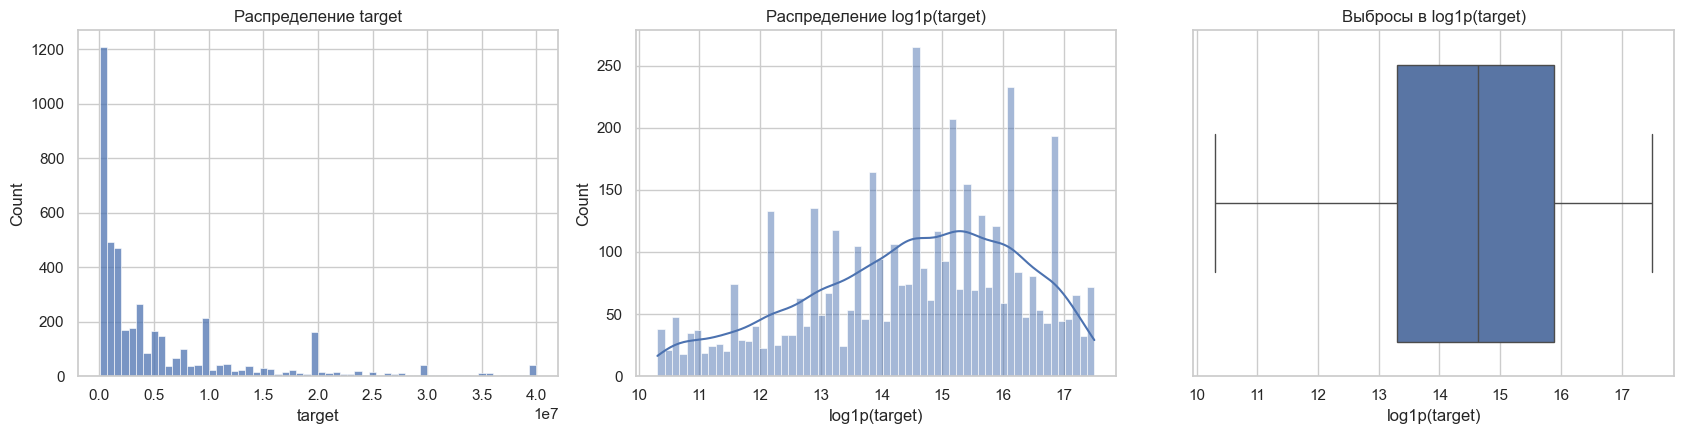

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.histplot(train[TARGET], bins=60, ax=axes[0])
axes[0].set_title("Распределение target")
axes[0].set_xlabel("target")

log_target = np.log1p(train[TARGET])
sns.histplot(log_target, bins=60, kde=True, ax=axes[1])
axes[1].set_title("Распределение log1p(target)")
axes[1].set_xlabel("log1p(target)")

sns.boxplot(x=log_target, ax=axes[2])
axes[2].set_title("Выбросы в log1p(target)")
axes[2].set_xlabel("log1p(target)")

plt.tight_layout()
plt.show()

In [5]:
feature_nunique = train[RAW_FEATURES].nunique()
constant_cols = feature_nunique[feature_nunique <= 1].index.tolist()
feature_cols = [c for c in RAW_FEATURES if c not in constant_cols]

feature_summary = pd.Series({
    "Все признаки": len(RAW_FEATURES),
    "Константные": len(constant_cols),
    "Осталось": len(feature_cols),
})
display(feature_summary.to_frame("Количество"))

,Количество
Все признаки,4991
Константные,256
Осталось,4735


,Значение
Среднее ненулевых признаков в строке,157.010316
Медиана ненулевых признаков в строке,103.000000
"Средняя доля ненулевых, %",3.315952


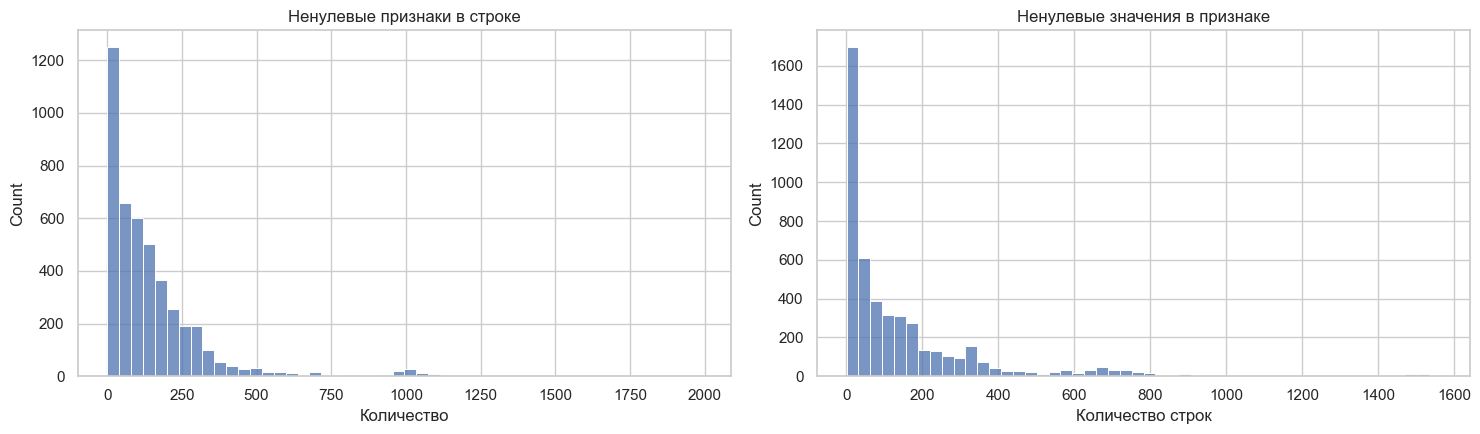

In [6]:
nonzero_per_row = train[feature_cols].ne(0).sum(axis=1)
nonzero_per_feature = train[feature_cols].ne(0).sum(axis=0)

sparsity = pd.Series({
    "Среднее ненулевых признаков в строке": nonzero_per_row.mean(),
    "Медиана ненулевых признаков в строке": nonzero_per_row.median(),
    "Средняя доля ненулевых, %": 100 * nonzero_per_row.mean() / len(feature_cols),
})
display(sparsity.to_frame("Значение"))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

sns.histplot(nonzero_per_row, bins=50, ax=axes[0])
axes[0].set_title("Ненулевые признаки в строке")
axes[0].set_xlabel("Количество")

sns.histplot(nonzero_per_feature, bins=50, ax=axes[1])
axes[1].set_title("Ненулевые значения в признаке")
axes[1].set_xlabel("Количество строк")

plt.tight_layout()
plt.show()

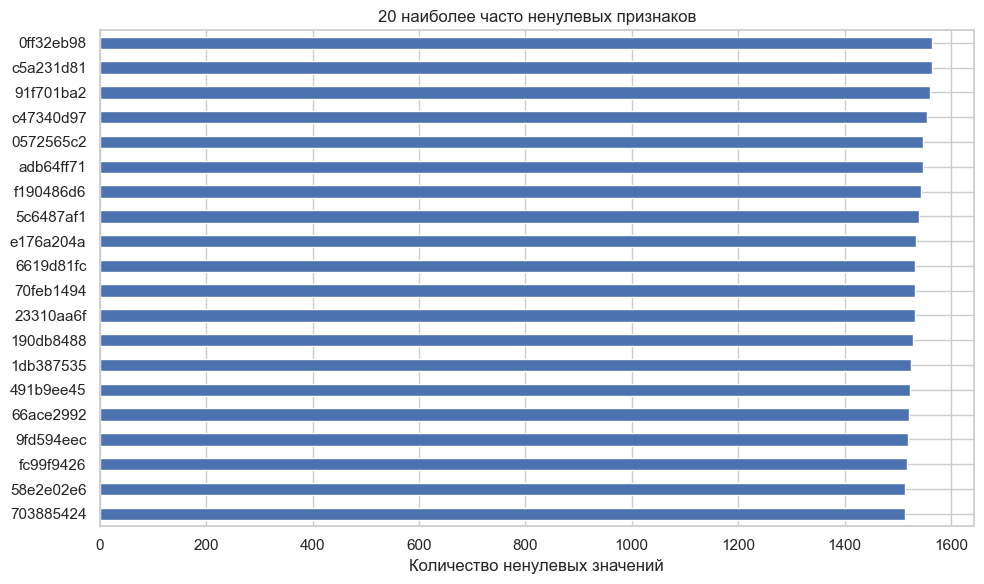

In [7]:
top_active = nonzero_per_feature.nlargest(20).sort_values()

plt.figure(figsize=(10, 6))
top_active.plot(kind="barh")
plt.title("20 наиболее часто ненулевых признаков")
plt.xlabel("Количество ненулевых значений")
plt.ylabel("")
plt.tight_layout()
plt.show()

,correlation,abs_correlation
9fd594eec,0.197227,0.197227
f190486d6,0.195313,0.195313
6eef030c1,0.194630,0.194630
58e2e02e6,0.187259,0.187259
70feb1494,0.173549,0.173549
f74e8f13d,0.172804,0.172804
26fc93eb7,0.172285,0.172285
1702b5bf0,0.168431,0.168431
fb49e4212,0.167091,0.167091
58232a6fb,0.163608,0.163608


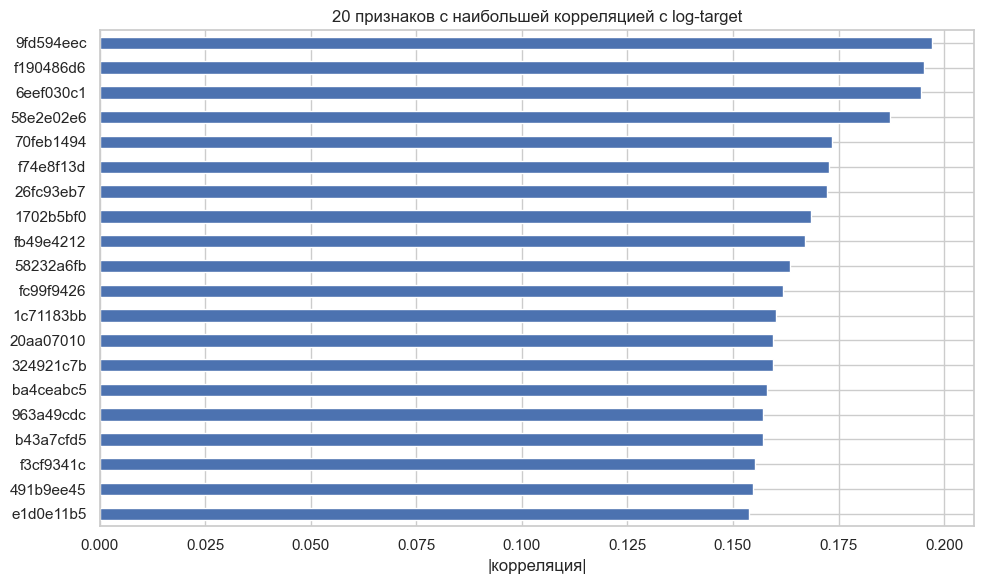

In [8]:
correlations = train[feature_cols].corrwith(log_target)
top_corr = correlations.abs().nlargest(20).sort_values()

display(
    pd.DataFrame({
        "correlation": correlations.loc[top_corr.index],
        "abs_correlation": top_corr,
    }).sort_values("abs_correlation", ascending=False)
)

plt.figure(figsize=(10, 6))
top_corr.plot(kind="barh")
plt.title("20 признаков с наибольшей корреляцией с log-target")
plt.xlabel("|корреляция|")
plt.ylabel("")
plt.tight_layout()
plt.show()

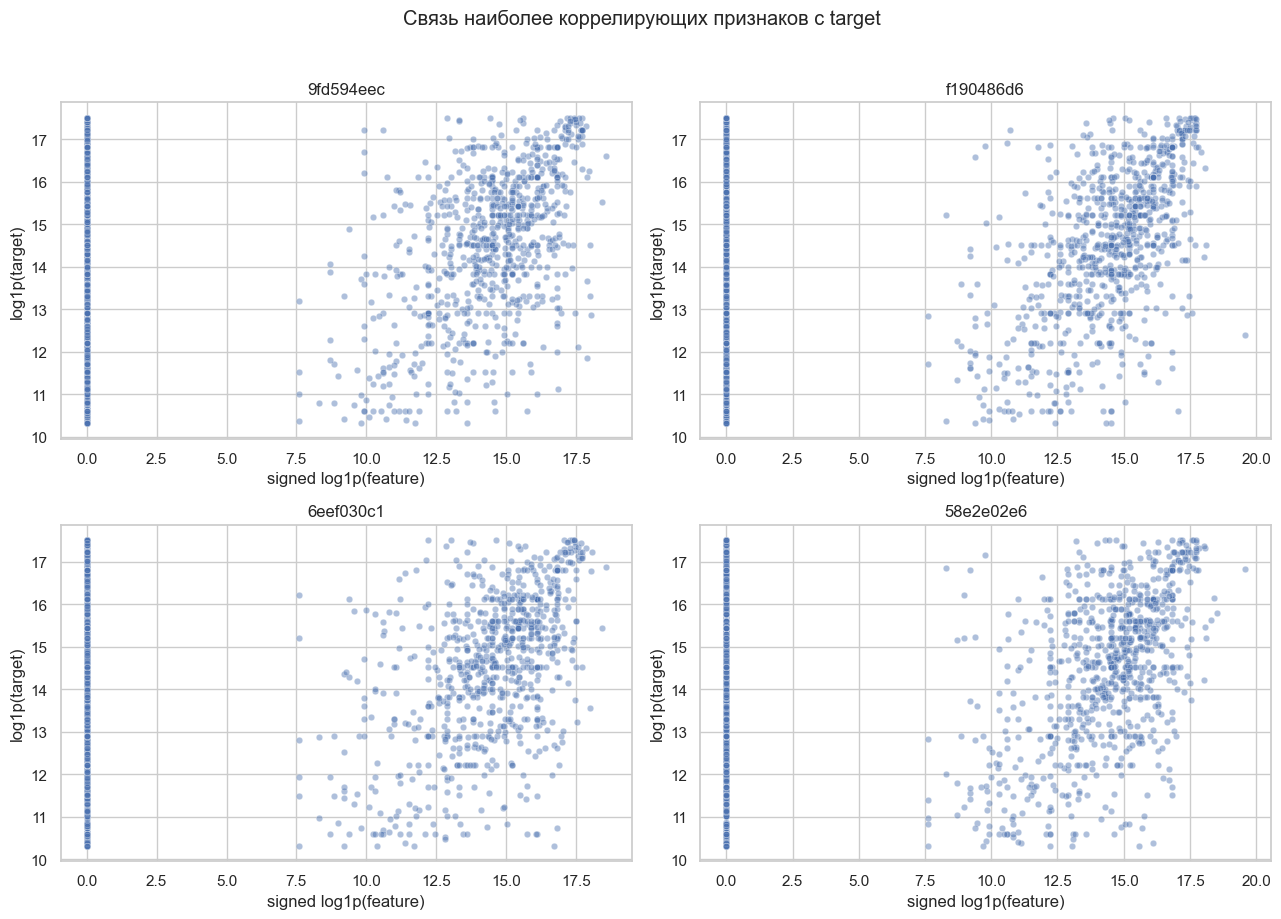

In [9]:
scatter_cols = top_corr.nlargest(4).index
sample_idx = train.sample(min(2500, len(train)), random_state=RANDOM_STATE).index

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col in zip(axes.ravel(), scatter_cols):
    x = np.sign(train.loc[sample_idx, col]) * np.log1p(np.abs(train.loc[sample_idx, col]))
    sns.scatterplot(x=x, y=log_target.loc[sample_idx], s=22, alpha=0.45, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("signed log1p(feature)")
    ax.set_ylabel("log1p(target)")

plt.suptitle("Связь наиболее коррелирующих признаков с target", y=1.02)
plt.tight_layout()
plt.show()

### Выводы EDA

- `target` сильно скошен, поэтому используем `log1p(target)`;
- в данных много константных и нулевых значений;
- отдельные признаки слабо объясняют цель, поэтому добавим статистики по строкам и сравним несколько моделей.

## 4. Feature engineering

In [10]:
def make_row_features(df, columns):
    values = np.abs(df[columns].to_numpy(dtype=np.float32))
    nonzero_count = (values > 0).sum(axis=1).astype(np.float32)
    safe_count = np.maximum(nonzero_count, 1)

    abs_sum = values.sum(axis=1)
    abs_mean = abs_sum / safe_count
    abs_std = np.sqrt(
        np.maximum((values ** 2).sum(axis=1) / safe_count - abs_mean ** 2, 0)
    )
    abs_max = values.max(axis=1)

    log_values = np.log1p(values)
    log_sum = log_values.sum(axis=1)
    log_mean = log_sum / safe_count
    log_std = np.sqrt(
        np.maximum((log_values ** 2).sum(axis=1) / safe_count - log_mean ** 2, 0)
    )

    return pd.DataFrame({
        "row_nonzero_count": nonzero_count,
        "row_zero_fraction": 1 - nonzero_count / len(columns),
        "row_abs_sum": abs_sum,
        "row_abs_mean": abs_mean,
        "row_abs_std": abs_std,
        "row_abs_max": abs_max,
        "row_log_sum": log_sum,
        "row_log_mean": log_mean,
        "row_log_std": log_std,
    }, index=df.index)

In [11]:
top_raw_cols = nonzero_per_feature.nlargest(
    min(N_TOP_RAW_FEATURES, len(nonzero_per_feature))
).index.tolist()

row_train = make_row_features(train, feature_cols)
row_test = make_row_features(test, feature_cols)

display(row_train.describe().T)

,count,mean,std,min,25%,50%,75%,max
row_nonzero_count,4459.0,1.570103e+02,2.120844e+02,1.000000,3.400000e+01,1.030000e+02,1.970000e+02,1.989000e+03
row_zero_fraction,4459.0,9.668404e-01,4.479100e-02,0.579937,9.583949e-01,9.782471e-01,9.928194e-01,9.997888e-01
row_abs_sum,4459.0,1.388579e+09,2.405995e+09,4000.000000,1.255689e+08,5.302845e+08,1.518062e+09,2.273640e+10
row_abs_mean,4459.0,9.841898e+06,1.459619e+07,4000.000000,2.313470e+06,6.082092e+06,1.205906e+07,4.000000e+08
row_abs_std,4459.0,1.328001e+07,2.228125e+07,0.000000,2.661805e+06,8.271002e+06,1.706614e+07,3.095759e+08
row_abs_max,4459.0,9.071127e+07,2.478598e+08,4000.000000,1.224000e+07,4.070000e+07,1.000000e+08,4.652000e+09
row_log_sum,4459.0,2.247857e+03,3.048536e+03,8.294300,4.916877e+02,1.444217e+03,2.766925e+03,2.939814e+04
row_log_mean,4459.0,1.441427e+01,1.515830e+00,8.047450,1.358275e+01,1.445566e+01,1.532737e+01,1.980697e+01
row_log_std,4459.0,1.416058e+00,6.550222e-01,0.000000,9.829091e-01,1.440035e+00,1.821389e+00,4.893127e+00


In [12]:
def signed_log1p(df, columns):
    values = df[columns].to_numpy(dtype=np.float32)
    return np.sign(values) * np.log1p(np.abs(values))


X_train = np.hstack([
    signed_log1p(train, top_raw_cols),
    row_train.to_numpy(dtype=np.float32),
])

X_test = np.hstack([
    signed_log1p(test, top_raw_cols),
    row_test.to_numpy(dtype=np.float32),
])

feature_names = [f"log_{c}" for c in top_raw_cols] + row_train.columns.tolist()

y = train[TARGET].to_numpy(dtype=np.float64)
y_log = np.log1p(y)

print("Матрица train:", X_train.shape)
print("Матрица test: ", X_test.shape)

Матрица train: (4459, 609)
Матрица test:  (49342, 609)


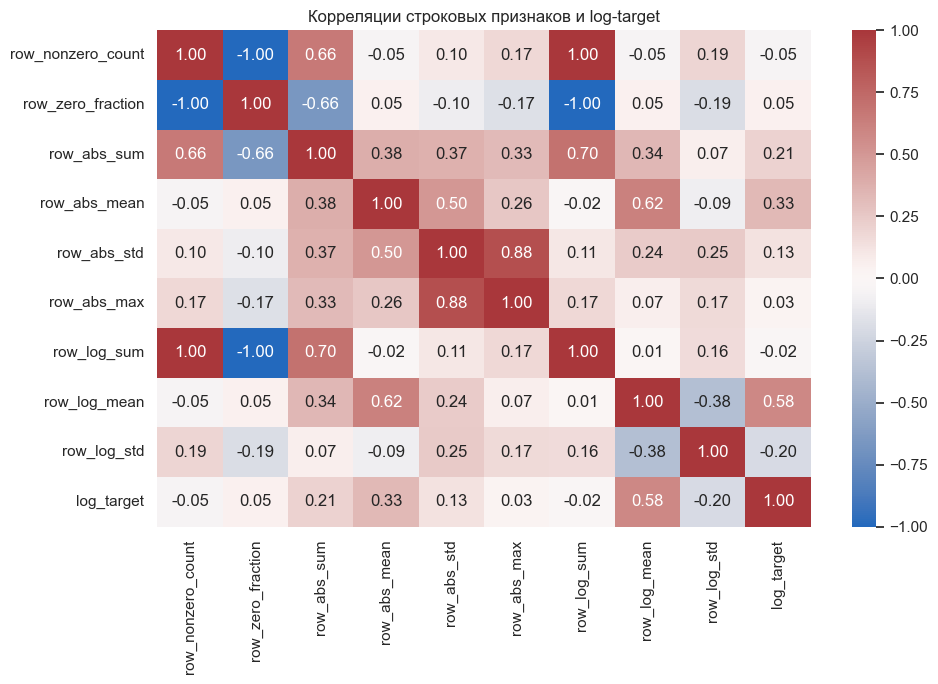

In [13]:
eda_features = row_train.copy()
eda_features["log_target"] = y_log

plt.figure(figsize=(10, 7))
sns.heatmap(
    eda_features.corr(),
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
)
plt.title("Корреляции строковых признаков и log-target")
plt.tight_layout()
plt.show()

## 5. Метрика и кросс-валидация

Все сравниваемые модели получают **одну и ту же матрицу из 609 признаков**: 600 наиболее активных исходных столбцов после `signed_log1p` и 9 агрегатов по строке. Для всех моделей используются одинаковые стратифицированные фолды. Это делает различия в CV RMSLE следствием алгоритма, а не разного набора входных данных.


In [14]:
def rmsle_log(y_true_log, y_pred_log):
    return np.sqrt(mean_squared_error(y_true_log, y_pred_log))


target_bins = pd.qcut(y_log, q=10, labels=False, duplicates="drop")

# Отдельные фолды для подбора параметров
search_cv = StratifiedKFold(
    n_splits=N_TUNING_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE + 1,
)
search_folds = list(search_cv.split(X_train, target_bins))

# Общие фолды для финального сравнения лучших моделей
final_cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
folds = list(final_cv.split(X_train, target_bins))

In [15]:
def evaluate_model(name, model, X_fit, X_predict):
    oof = np.zeros(len(y_log))
    test_pred = np.zeros(len(X_predict))
    fold_scores = []

    start = time.time()

    for fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        estimator = clone(model)
        estimator.fit(X_fit[train_idx], y_log[train_idx])

        valid_pred = estimator.predict(X_fit[valid_idx])
        oof[valid_idx] = valid_pred
        test_pred += estimator.predict(X_predict) / N_SPLITS

        score = rmsle_log(y_log[valid_idx], valid_pred)
        fold_scores.append(score)
        print(f"{name}, fold {fold}: {score:.5f}")

    result = {
        "model": name,
        "cv_rmsle": rmsle_log(y_log, oof),
        "fold_std": np.std(fold_scores),
        "minutes": (time.time() - start) / 60,
    }
    return result, oof, test_pred

### Результаты подбора параметров

Для каждой модели сравниваем несколько конфигураций по CV RMSLE. Меньше — лучше.

In [16]:
search_objects = {}
search_tables = {}


def show_search_results(model_name, search, top_n=10):
    table = pd.DataFrame(search.cv_results_)
    param_cols = [c for c in table.columns if c.startswith("param_")]

    table = table[
        ["rank_test_score", "mean_test_score", "std_test_score", "mean_fit_time"]
        + param_cols
    ].copy()

    table["cv_rmsle"] = -table.pop("mean_test_score")
    table = table.rename(columns={
        "rank_test_score": "rank",
        "std_test_score": "cv_std",
        "mean_fit_time": "fit_seconds",
    }).sort_values("rank").reset_index(drop=True)

    search_objects[model_name] = search
    search_tables[model_name] = table

    display(table.head(top_n))

    plot_data = table.head(top_n).copy()
    plot_data["configuration"] = [f"#{i}" for i in range(1, len(plot_data) + 1)]

    plt.figure(figsize=(8, 4))
    sns.barplot(data=plot_data, x="cv_rmsle", y="configuration")
    plt.title(f"{model_name}: лучшие комбинации")
    plt.xlabel("CV RMSLE")
    plt.ylabel("Место")
    plt.tight_layout()
    plt.show()

    print("Лучшие параметры:", search.best_params_)
    print(f"Лучший tuning CV RMSLE: {-search.best_score_:.6f}")

    return table

## 6. Baseline и модели

In [17]:
results = []
oof_predictions = {}
test_predictions = {}

baseline = DummyRegressor(strategy="median")
result, oof, pred = evaluate_model(
    "Dummy median",
    baseline,
    row_train.to_numpy(dtype=np.float32),
    row_test.to_numpy(dtype=np.float32),
)

results.append(result)
oof_predictions[result["model"]] = oof
test_predictions[result["model"]] = pred

Dummy median, fold 1: 1.77272
Dummy median, fold 2: 1.76331
Dummy median, fold 3: 1.75207
Dummy median, fold 4: 1.74409
Dummy median, fold 5: 1.74967


### Ridge: GridSearchCV

Проверяем одновременно силу регуляризации `alpha` и число отобранных признаков.

,rank,cv_std,fit_seconds,param_ridge__alpha,param_select__k,cv_rmsle
0,1,0.042201,0.040728,100.0,100,1.425228
1,2,0.044567,0.042953,10.0,100,1.425954
2,3,0.044884,0.041378,1.0,100,1.426173
3,4,0.044917,0.085983,0.1,100,1.426196
4,5,0.042432,0.050340,100.0,200,1.446627
5,6,0.034450,0.043792,1000.0,100,1.449185
6,7,0.044418,0.047644,10.0,200,1.451176
7,8,0.044686,0.049673,1.0,200,1.451745
8,9,0.044712,0.063059,0.1,200,1.451779
9,10,0.035923,0.048761,1000.0,200,1.457137


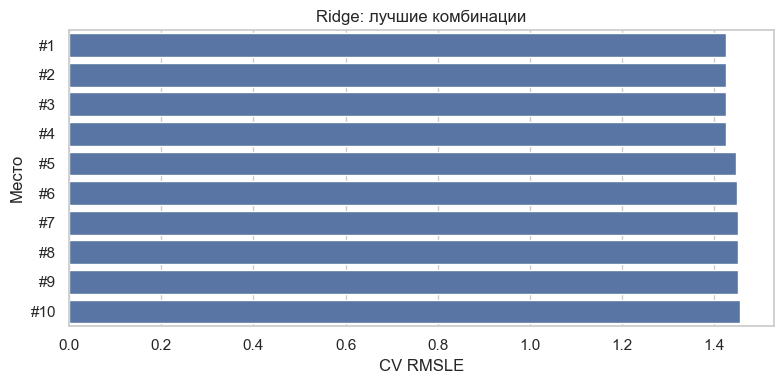

Лучшие параметры: {'ridge__alpha': 100, 'select__k': 100}
Лучший tuning CV RMSLE: 1.425228
Ridge, fold 1: 1.41523


Ridge, fold 2: 1.40208
Ridge, fold 3: 1.46723


Ridge, fold 4: 1.44190


Ridge, fold 5: 1.43044


In [18]:
ridge_pipeline = Pipeline([
    ("select", SelectKBest(f_regression)),
    ("scale", StandardScaler()),
    ("ridge", Ridge()),
])

ridge_grid = {
    "select__k": [100, 200, 400, "all"],
    "ridge__alpha": [0.1, 1, 10, 100, 1000],
}

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_grid,
    scoring="neg_root_mean_squared_error",
    cv=search_folds,
    n_jobs=N_JOBS,
    return_train_score=True,
)

ridge_search.fit(X_train, y_log)
show_search_results("Ridge", ridge_search)

ridge_model = ridge_search.best_estimator_

result, oof, pred = evaluate_model(
    "Ridge",
    ridge_model,
    X_train,
    X_test,
)

results.append(result)
oof_predictions[result["model"]] = oof
test_predictions[result["model"]] = pred

### ExtraTrees: RandomizedSearchCV

,rank,cv_std,fit_seconds,param_n_estimators,param_min_samples_leaf,param_max_features,param_max_depth,cv_rmsle
0,1,0.045310,37.897301,350,8,1.0,None,1.346857
1,2,0.052975,47.695556,350,2,0.7,None,1.349007
2,3,0.044722,101.882430,350,8,0.7,12,1.351031
3,4,0.053662,11.177433,200,2,0.3,30,1.352702
4,5,0.046367,39.926334,200,1,0.5,12,1.353852


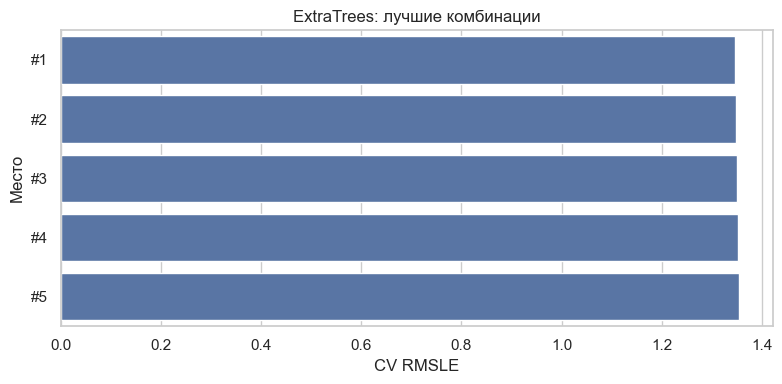

Лучшие параметры: {'n_estimators': 350, 'min_samples_leaf': 8, 'max_features': 1.0, 'max_depth': None}
Лучший tuning CV RMSLE: 1.346857


ExtraTrees, fold 1: 1.31324


ExtraTrees, fold 2: 1.32177


ExtraTrees, fold 3: 1.38221


ExtraTrees, fold 4: 1.36496


ExtraTrees, fold 5: 1.32496


In [19]:
extra_search = RandomizedSearchCV(
    estimator=ExtraTreesRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    param_distributions={
        "n_estimators": [200, 350],
        "max_features": [0.3, 0.5, 0.7, 1.0],
        "min_samples_leaf": [1, 2, 4, 8],
        "max_depth": [None, 12, 20, 30],
    },
    n_iter=N_SEARCH_ITER,
    scoring="neg_root_mean_squared_error",
    cv=search_folds,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    return_train_score=True,
)

extra_search.fit(X_train, y_log)
show_search_results("ExtraTrees", extra_search)

extra_trees = extra_search.best_estimator_.set_params(n_jobs=N_JOBS)

result, oof, pred = evaluate_model(
    "ExtraTrees",
    extra_trees,
    X_train,
    X_test,
)

results.append(result)
oof_predictions[result["model"]] = oof
test_predictions[result["model"]] = pred

### RandomForest: RandomizedSearchCV

,rank,cv_std,fit_seconds,param_n_estimators,param_min_samples_leaf,param_max_features,param_max_depth,cv_rmsle
0,1,0.045290,36.207346,350,2,0.5,12,1.344414
1,2,0.043136,20.464973,350,8,0.3,20,1.344620
2,3,0.045440,17.231004,200,2,0.3,None,1.345202
3,4,0.044045,34.628406,350,8,0.5,None,1.345601
4,5,0.045457,21.593672,200,1,0.3,30,1.348208


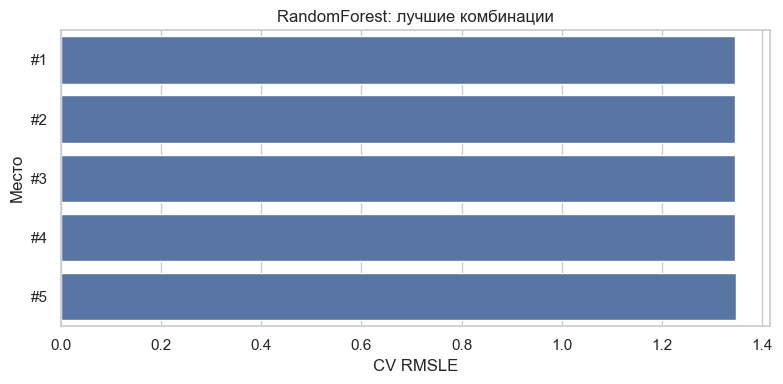

Лучшие параметры: {'n_estimators': 350, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 12}
Лучший tuning CV RMSLE: 1.344414


RandomForest, fold 1: 1.31099


RandomForest, fold 2: 1.33936


RandomForest, fold 3: 1.37463


RandomForest, fold 4: 1.36146


RandomForest, fold 5: 1.32283


In [20]:
forest_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    param_distributions={
        "n_estimators": [200, 350],
        "max_features": [0.3, 0.5, 0.7, 1.0],
        "min_samples_leaf": [1, 2, 4, 8],
        "max_depth": [None, 12, 20, 30],
    },
    n_iter=N_SEARCH_ITER,
    scoring="neg_root_mean_squared_error",
    cv=search_folds,
    random_state=RANDOM_STATE + 1,
    n_jobs=N_JOBS,
    return_train_score=True,
)

forest_search.fit(X_train, y_log)
show_search_results("RandomForest", forest_search)

random_forest = forest_search.best_estimator_.set_params(n_jobs=N_JOBS)

result, oof, pred = evaluate_model(
    "RandomForest",
    random_forest,
    X_train,
    X_test,
)

results.append(result)
oof_predictions[result["model"]] = oof
test_predictions[result["model"]] = pred

### HistGradientBoosting: RandomizedSearchCV

,rank,cv_std,fit_seconds,param_min_samples_leaf,param_max_leaf_nodes,param_max_iter,param_learning_rate,param_l2_regularization,cv_rmsle
0,1,0.046859,13.786723,40,31,200,0.02,1.0,1.356854
1,2,0.043609,12.868461,10,15,300,0.02,1.0,1.362356
2,3,0.047593,29.732716,20,63,200,0.04,5.0,1.368034
3,4,0.047739,10.707422,20,15,300,0.07,0.0,1.378064
4,5,0.041797,42.228231,10,63,300,0.07,0.0,1.394787


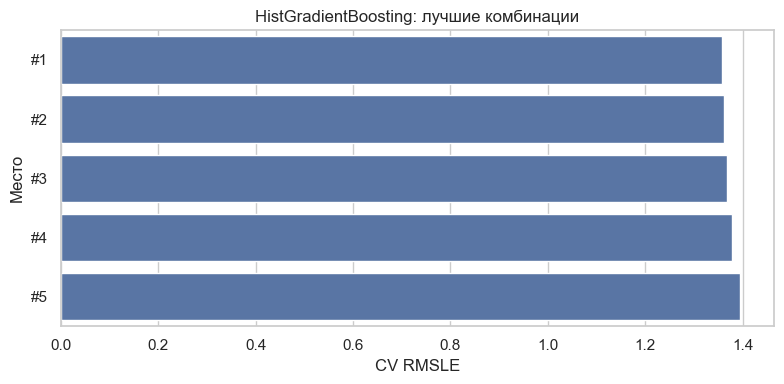

Лучшие параметры: {'min_samples_leaf': 40, 'max_leaf_nodes': 31, 'max_iter': 200, 'learning_rate': 0.02, 'l2_regularization': 1.0}
Лучший tuning CV RMSLE: 1.356854


HistGradientBoosting, fold 1: 1.31943


HistGradientBoosting, fold 2: 1.34836


HistGradientBoosting, fold 3: 1.39575


HistGradientBoosting, fold 4: 1.37343


HistGradientBoosting, fold 5: 1.31248


In [21]:
hist_search = RandomizedSearchCV(
    estimator=HistGradientBoostingRegressor(
        random_state=RANDOM_STATE,
    ),
    param_distributions={
        "learning_rate": [0.02, 0.04, 0.07, 0.1],
        "max_iter": [200, 300],
        "max_leaf_nodes": [15, 31, 63],
        "min_samples_leaf": [10, 20, 40],
        "l2_regularization": [0.0, 1.0, 5.0],
    },
    n_iter=N_SEARCH_ITER,
    scoring="neg_root_mean_squared_error",
    cv=search_folds,
    random_state=RANDOM_STATE + 2,
    n_jobs=N_JOBS,
    return_train_score=True,
)

# Та же матрица признаков, что у остальных моделей.
hist_search.fit(X_train, y_log)
show_search_results("HistGradientBoosting", hist_search)

hist_model = hist_search.best_estimator_

result, oof, pred = evaluate_model(
    "HistGradientBoosting",
    hist_model,
    X_train,
    X_test,
)

results.append(result)
oof_predictions[result["model"]] = oof
test_predictions[result["model"]] = pred


### LightGBM: RandomizedSearchCV

,rank,cv_std,fit_seconds,param_subsample,param_reg_lambda,param_reg_alpha,param_num_leaves,param_n_estimators,param_min_child_samples,param_max_depth,param_learning_rate,param_colsample_bytree,cv_rmsle
0,1,0.046116,5.929344,0.7,5.0,1.0,31,500,10,8,0.015,0.7,1.349676
1,2,0.049256,6.914758,0.9,5.0,0.1,24,800,40,8,0.015,0.9,1.359364
2,3,0.045051,12.291110,0.7,1.0,1.0,31,800,10,-1,0.015,0.7,1.360773
3,4,0.052054,6.037290,1.0,2.0,1.0,15,800,20,8,0.050,0.9,1.388238
4,5,0.048387,7.164600,0.7,1.0,0.1,15,800,10,8,0.050,0.9,1.394329


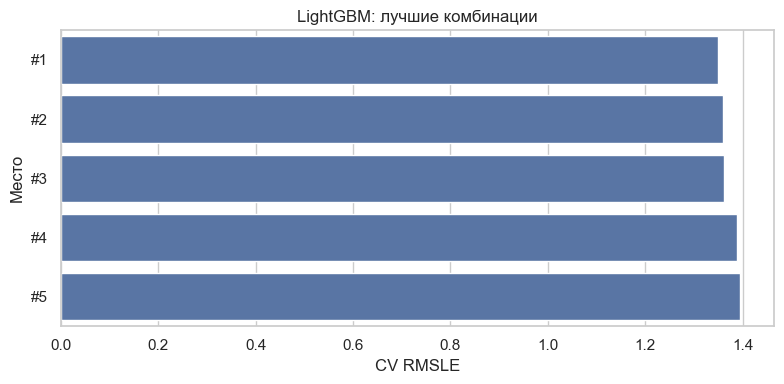

Лучшие параметры: {'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': 8, 'learning_rate': 0.015, 'colsample_bytree': 0.7}
Лучший tuning CV RMSLE: 1.349676


LightGBM, fold 1: 1.31472


LightGBM, fold 2: 1.34386


LightGBM, fold 3: 1.37333


LightGBM, fold 4: 1.37101


LightGBM, fold 5: 1.32486


In [22]:
if RUN_LIGHTGBM:
    from lightgbm import LGBMRegressor

    lightgbm_search = RandomizedSearchCV(
        estimator=LGBMRegressor(
            objective="regression",
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbosity=-1,
            subsample_freq=1,
        ),
        param_distributions={
            "n_estimators": [500, 800],
            "learning_rate": [0.015, 0.025, 0.05],
            "num_leaves": [15, 24, 31, 48],
            "max_depth": [-1, 8, 12],
            "min_child_samples": [10, 20, 40],
            "colsample_bytree": [0.5, 0.7, 0.9],
            "subsample": [0.7, 0.9, 1.0],
            "reg_alpha": [0.0, 0.1, 1.0],
            "reg_lambda": [1.0, 2.0, 5.0],
        },
        n_iter=N_SEARCH_ITER,
        scoring="neg_root_mean_squared_error",
        cv=search_folds,
        random_state=RANDOM_STATE + 3,
        n_jobs=N_JOBS,
        return_train_score=True,
    )

    lightgbm_search.fit(X_train, y_log)
    show_search_results("LightGBM", lightgbm_search)

    lightgbm = lightgbm_search.best_estimator_.set_params(n_jobs=N_JOBS)

    result, oof, pred = evaluate_model(
        "LightGBM",
        lightgbm,
        X_train,
        X_test,
    )

    results.append(result)
    oof_predictions[result["model"]] = oof
    test_predictions[result["model"]] = pred

### Сводка подбора

In [23]:
tuning_summary = pd.DataFrame([
    {
        "model": name,
        "best_tuning_cv_rmsle": -search.best_score_,
        "tested_configurations": len(search.cv_results_["params"]),
        "best_params": search.best_params_,
    }
    for name, search in search_objects.items()
]).sort_values("best_tuning_cv_rmsle").reset_index(drop=True)

display(tuning_summary)

all_search_results = pd.concat(
    [table.assign(model=name) for name, table in search_tables.items()],
    ignore_index=True,
)
all_search_results.to_csv("hyperparameter_search_results.csv", index=False)

print("Сохранён hyperparameter_search_results.csv")

,model,best_tuning_cv_rmsle,tested_configurations,best_params
0,RandomForest,1.344414,5,"{'n_estimators': 350, 'min_samples_leaf': 2, '..."
1,ExtraTrees,1.346857,5,"{'n_estimators': 350, 'min_samples_leaf': 8, '..."
2,LightGBM,1.349676,5,"{'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alp..."
3,HistGradientBoosting,1.356854,5,"{'min_samples_leaf': 40, 'max_leaf_nodes': 31,..."
4,Ridge,1.425228,20,"{'ridge__alpha': 100, 'select__k': 100}"


Сохранён hyperparameter_search_results.csv


## 7. Финальное сравнение лучших конфигураций

,model,cv_rmsle,fold_std,minutes
0,ExtraTrees,1.341706,0.027088,1.034798
1,RandomForest,1.342065,0.023579,1.033182
2,LightGBM,1.345767,0.023671,0.322680
3,HistGradientBoosting,1.350266,0.031583,0.560650
4,Ridge,1.431552,0.022434,0.017286
5,Dummy median,1.756405,0.010291,0.000190


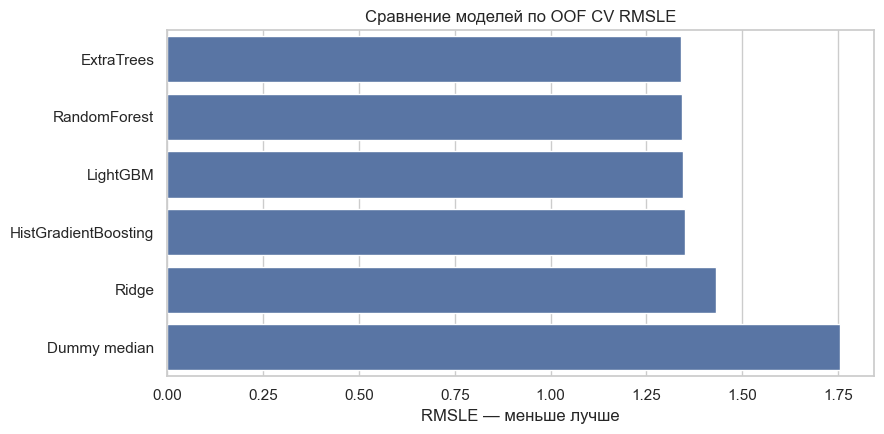

In [24]:
results_df = pd.DataFrame(results).sort_values("cv_rmsle").reset_index(drop=True)
display(results_df)

plt.figure(figsize=(9, 4.5))
sns.barplot(data=results_df, x="cv_rmsle", y="model")
plt.title("Сравнение моделей по OOF CV RMSLE")
plt.xlabel("RMSLE — меньше лучше")
plt.ylabel("")
plt.tight_layout()
plt.show()

model_templates = {
    "Ridge": ridge_model,
    "ExtraTrees": extra_trees,
    "RandomForest": random_forest,
    "HistGradientBoosting": hist_model,
}
if RUN_LIGHTGBM:
    model_templates["LightGBM"] = lightgbm


## 8. Weighted blend

In [25]:
candidate_names = (
    results_df.query("model != 'Dummy median'")
    .head(3)["model"]
    .tolist()
)

candidate_scores = (
    results_df.set_index("model")
    .loc[candidate_names, "cv_rmsle"]
)

blend_weights = 1 / candidate_scores
blend_weights = blend_weights / blend_weights.sum()

blend_oof = sum(
    blend_weights[name] * oof_predictions[name]
    for name in candidate_names
)
blend_score = rmsle_log(y_log, blend_oof)

weights_df = blend_weights.rename("weight").reset_index()
weights_df.columns = ["model", "weight"]

single_candidates = results_df.query("model != 'Dummy median'")[["model", "cv_rmsle"]]
selection_results = pd.concat([
    single_candidates,
    pd.DataFrame([{"model": "Weighted blend", "cv_rmsle": blend_score}]),
], ignore_index=True).sort_values("cv_rmsle").reset_index(drop=True)

best_variant = selection_results.iloc[0]["model"]
best_cv_rmsle = float(selection_results.iloc[0]["cv_rmsle"])

display(weights_df)
display(selection_results)
print(f"Победитель по OOF CV: {best_variant}, RMSLE={best_cv_rmsle:.6f}")


,model,weight
0,ExtraTrees,0.333699
1,RandomForest,0.333609
2,LightGBM,0.332692


,model,cv_rmsle
0,Weighted blend,1.336892
1,ExtraTrees,1.341706
2,RandomForest,1.342065
3,LightGBM,1.345767
4,HistGradientBoosting,1.350266
5,Ridge,1.431552


Победитель по OOF CV: Weighted blend, RMSLE=1.336892


## 9. Feature importance

,importance
row_log_mean,0.404733
row_abs_mean,0.067422
row_log_std,0.026453
log_f190486d6,0.017008
row_abs_std,0.015584
row_abs_sum,0.008999
row_abs_max,0.008907
log_58e2e02e6,0.008614
log_eeb9cd3aa,0.006716
log_9fd594eec,0.006709


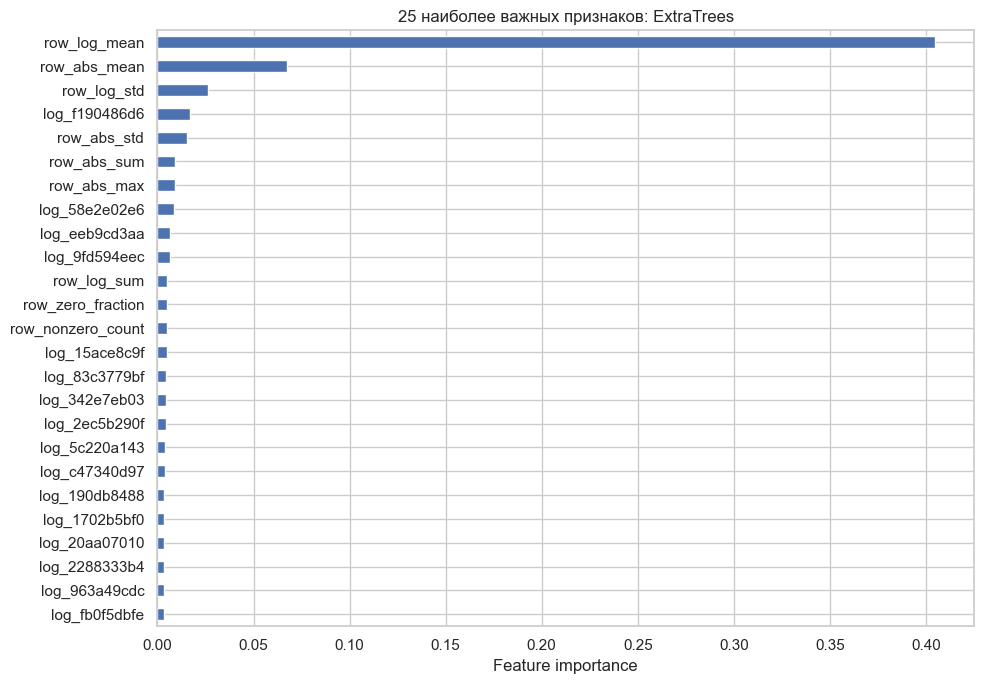

In [26]:
tree_candidates = [name for name in ["ExtraTrees", "RandomForest"] if name in model_templates]
importance_name = min(
    tree_candidates,
    key=lambda name: float(results_df.set_index("model").loc[name, "cv_rmsle"]),
)
importance_model = clone(model_templates[importance_name])
importance_model.fit(X_train, y_log)

importance = pd.Series(
    importance_model.feature_importances_,
    index=feature_names,
).sort_values(ascending=False)

display(importance.head(25).rename("importance").to_frame())

plt.figure(figsize=(10, 7))
importance.head(25).sort_values().plot(kind="barh")
plt.title(f"25 наиболее важных признаков: {importance_name}")
plt.xlabel("Feature importance")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 10. Финальное обучение и артефакты

Вариант выбирается **только по OOF CV на train**. После выбора победитель переобучается на всех 4 459 обучающих строках. Kaggle test не участвует ни в настройке, ни в выборе модели.


In [27]:
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

if best_variant == "Weighted blend":
    final_log_prediction = np.zeros(len(X_test), dtype=np.float64)
    fitted_components = {}
    for name, weight in blend_weights.items():
        print(f"Обучение {name} на полном train; вес={weight:.4f}")
        estimator = clone(model_templates[name])
        estimator.fit(X_train, y_log)
        fitted_components[name] = estimator
        final_log_prediction += weight * estimator.predict(X_test)
    final_details = {
        "variant": best_variant,
        "components": {name: float(weight) for name, weight in blend_weights.items()},
    }
else:
    print(f"Обучение {best_variant} на полном train")
    final_model = clone(model_templates[best_variant])
    final_model.fit(X_train, y_log)
    final_log_prediction = final_model.predict(X_test)
    final_details = {"variant": best_variant}

final_prediction = np.clip(np.expm1(final_log_prediction), 0, None)
submission = sample_sub.copy()
submission[TARGET] = final_prediction
submission_path = ARTIFACTS_DIR / "submission_final.csv"
submission.to_csv(submission_path, index=False)

display(submission.head())
print("Сохранён", submission_path)


Обучение ExtraTrees на полном train; вес=0.3337


Обучение RandomForest на полном train; вес=0.3336


Обучение LightGBM на полном train; вес=0.3327


,ID,target
0,000137c73,1.784337e+06
1,00021489f,1.931920e+06
2,0004d7953,1.847625e+06
3,00056a333,3.049657e+06
4,00056d8eb,1.540370e+06


Сохранён artifacts\submission_final.csv


In [28]:
selection_path = ARTIFACTS_DIR / "model_selection.csv"
selection_results.to_csv(selection_path, index=False)

importance_path = ARTIFACTS_DIR / "feature_importance.csv"
importance.rename("importance").to_csv(importance_path, header=True)

run_summary = {
    "selection_metric": "OOF CV RMSLE",
    "best_variant": best_variant,
    "best_cv_rmsle": best_cv_rmsle,
    "n_train_rows": int(len(train)),
    "n_test_rows": int(len(test)),
    "n_model_features": int(X_train.shape[1]),
    **final_details,
}
summary_path = ARTIFACTS_DIR / "run_summary.json"
summary_path.write_text(
    json.dumps(run_summary, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("Сохранены:")
print("-", selection_path)
print("-", importance_path)
print("-", summary_path)


Сохранены:
- artifacts\model_selection.csv
- artifacts\feature_importance.csv
- artifacts\run_summary.json


## 11. Итоги

In [29]:
display(Markdown(f"""
### Зафиксированный результат

- Все алгоритмы сравнивались на одинаковых **{X_train.shape[1]} признаках** и одинаковых пяти фолдах.
- Победитель выбран без использования Kaggle test: **{best_variant}**.
- OOF CV RMSLE победителя: **{best_cv_rmsle:.6f}**.
- После выбора победитель переобучен на всём train, а прогноз сохранён в `{submission_path}`.
- Таблица выбора и параметры запуска сохранены в каталоге `artifacts/`.

Разреженность исходных 4 991 признаков остаётся главным ограничением: CV показывает качество на доступной обучающей выборке, но окончательная внешняя оценка определяется Kaggle leaderboard.
"""))



### Зафиксированный результат

- Все алгоритмы сравнивались на одинаковых **609 признаках** и одинаковых пяти фолдах.
- Победитель выбран без использования Kaggle test: **Weighted blend**.
- OOF CV RMSLE победителя: **1.336892**.
- После выбора победитель переобучен на всём train, а прогноз сохранён в `artifacts\submission_final.csv`.
- Таблица выбора и параметры запуска сохранены в каталоге `artifacts/`.

Разреженность исходных 4 991 признаков остаётся главным ограничением: CV показывает качество на доступной обучающей выборке, но окончательная внешняя оценка определяется Kaggle leaderboard.
